In [1]:
import os

if not os.path.exists("COVID-ML"):
    !git clone https://github.com/vinimicius/COVID-ML.git
%cd COVID-ML

/content/COVID-ML


In [ ]:
!git checkout feat-random-forest

In [2]:
import os
import pandas as pd
from data_utils import run_pipeline

# Caminho do dado tratado
READY_DATA_PATH = 'data/data_ready.csv'

if os.path.exists(READY_DATA_PATH):
    print(f"✅ Carregando dados já tratados de: {READY_DATA_PATH}")
    df = pd.read_csv(READY_DATA_PATH)
else:
    print("🚀 Dados tratados não encontrados. Iniciando pipeline completa...")
    df = run_pipeline(export=True)

df.head()

✅ Carregando dados já tratados de: data/data_ready.csv


,F,M,idade,obito,asma,cardiopatia,diabetes,doenca_hematologica,doenca_hepatica,doenca_neurologica,doenca_renal,imunodepressao,obesidade,outros_fatores_de_risco,pneumopatia,puerpera,sindrome_de_down
0,0,1,0.738739,1,0,0,1,0,0,0,0,0,0,1,0,0,0
1,1,0,0.270270,1,0,0,1,0,0,0,0,0,1,0,0,0,0
2,0,1,0.288288,1,0,1,0,0,0,0,0,0,0,1,0,0,0
3,0,1,0.621622,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,1,0.702703,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Definição clara para o leitor do notebook
AGE_GROUPS = {
    'jovem': (0, 30),
    'jovem-adulto': (20, 40),
    'adulto': (40, 60),
    'senior': (60, 80),
    'idoso': (80, 120)
}

In [ ]:
# Dicionário que servirá como nosso banco de dados de resultados
all_reports = {}

# Definimos o nosso grid aqui para ser consistente
meu_grid_final = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
from model_utils import (
    split_age_groups, 
    run_random_forest_pipeline, 
    get_model_predictions,
    display_group_report,
    export_visual_reports,
    save_model_assets
)

from sklearn.model_selection import train_test_split

# Separar os dados por faixa etária
groups = split_age_groups(df, AGE_GROUPS)


for name, group_df in groups.items():
    print(f"\n--- Processando Grupo: {name.upper()} ---")
    
    # 3. Preparação dos Dados
    X = group_df.drop(columns=['obito', 'idade_raw'], errors = 'ignore')
    y = group_df['obito']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 4. Treino e Otimização (GridSearch via model_utils)
    best_model, best_params = run_random_forest_pipeline(X_train, y_train, name, param_grid=meu_grid_final)
    
    # 5. Predições
    y_pred, y_proba = get_model_predictions(best_model, X_test)

    # 6. EXIBIÇÃO E ARMAZENAMENTO (A parte que você perguntou)
    # A função printa o relatório na tela e guarda o DataFrame no dicionário
    all_reports[name] = display_group_report(y_test, y_pred, y_proba, name)

    # 7. Persistência (Salva o .pkl e o .json)
    save_model_assets(best_model, best_params, name)
    
    # 8. Exportação Silenciosa de Gráficos (Matriz de Confusão e Feature Importance)
    export_visual_reports(best_model, X_test, y_test, y_pred, name)
    
print("\n✅ Todos os grupos foram processados e armazenados em 'all_reports'!")

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

group_name = 'todos'

print(f"\n\n--- Treinando modelo Random Forest para o grupo: {group_name} ---")
X = df_new.drop(columns=['obito'])
y = df_new['obito']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Formato dos dados de treino: {X_train.shape}")
print(f"Formato dos dados de teste: {X_test.shape}\n")

rf_clf = RandomForestClassifier(
    criterion='entropy',
    random_state=42,
    class_weight='balanced',
    n_jobs=10,
)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [20, 50, 100, 200, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

print(f'\nComeçando o Grid Search para o grupo: {group_name}')
grid_search = GridSearchCV(rf_clf, param_grid, cv=3, scoring="roc_auc", verbose=3)
resultado = grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Maior AUC durante a validação cruzada:", grid_search.best_score_)
print("AUC do conjunto de treino", grid_search.score(X_train, y_train))
print("AUC do conjunto de teste:\n", grid_search.score(X_test, y_test))

print(f'\nComeçando o treinamento final do modelo RF para o grupo: {group_name}')
rf_clf = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    criterion='entropy',
    random_state=42,
    class_weight='balanced',
    n_jobs=10,
)

rf_clf.fit(X_train, y_train)



--- Treinando modelo Random Forest para o grupo: todos ---
Formato dos dados de treino: (161463, 16)
Formato dos dados de teste: (40366, 16)


Começando o Grid Search para o grupo: todos
Fitting 3 folds for each of 180 candidates, totalling 540 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.617 total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.620 total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.622 total time=   0.1s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.618 total time=   0.4s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.620 total time=   0.4s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.622 total time=   0.4s
[CV 1/3] END max_depth=None, min_s

,n_estimators,400
,criterion,'entropy'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Acurácia - treino: 0.6099849501124096
Acurácia - teste: 0.6096467323985533
F1-Score - treino: 0.5540376893496781
F1-Score - teste: 0.5545472535549713

--- Relatório de Classificação - teste ---
              precision    recall  f1-score   support

           0       0.76      0.57      0.65     25808
           1       0.47      0.67      0.55     14558

    accuracy                           0.61     40366
   macro avg       0.61      0.62      0.60     40366
weighted avg       0.65      0.61      0.62     40366


--- Matriz de Confusão - teste ---
[[14801 11007]
 [ 4750  9808]]


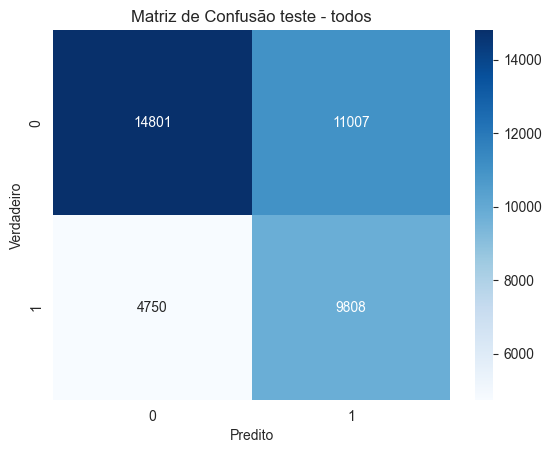

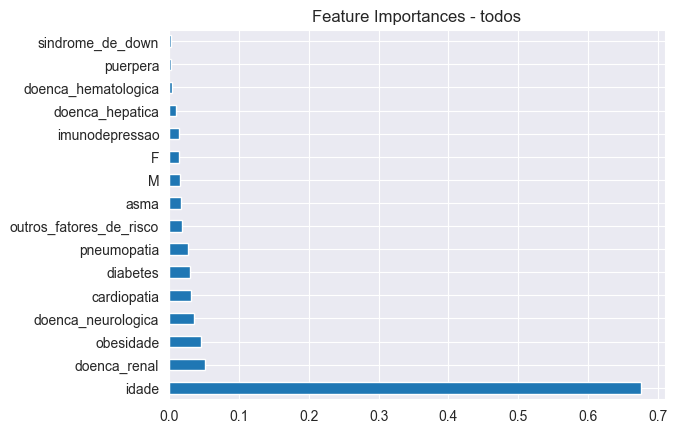



--- Avaliando modelo Random Forest para o grupo: jovem ---
Acurácia - jovem: 0.8655521213824108
F1-Score - jovem: 0.010341261633919338
ROC-AUC - jovem: 0.5024417762801775 


--- Relatório de Classificação - jovem ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      6158
           1       0.71      0.01      0.01       960

    accuracy                           0.87      7118
   macro avg       0.79      0.50      0.47      7118
weighted avg       0.85      0.87      0.80      7118


--- Matriz de Confusão - jovem ---
[[6156    2]
 [ 955    5]]


--- Avaliando modelo Random Forest para o grupo: jovem-adulto ---
Acurácia - jovem-adulto: 0.8140715381891158
F1-Score - jovem-adulto: 0.03136531365313653
ROC-AUC - jovem-adulto: 0.5070197816445348 


--- Relatório de Classificação - jovem-adulto ---
              precision    recall  f1-score   support

           0       0.81      1.00      0.90     13769
           1       0.65      

In [22]:


y_pred_train = rf_clf.predict(X_train) # predição para o conjunto de treino
y_pred_test = rf_clf.predict(X_test) # predição para o conjunto de teste
print("\nAcurácia - treino:", accuracy_score(y_train, y_pred_train))
print("Acurácia - teste:", accuracy_score(y_test, y_pred_test))
print("F1-Score - treino:", f1_score(y_train, y_pred_train, average='binary'))
print("F1-Score - teste:", f1_score(y_test, y_pred_test))
print("\n--- Relatório de Classificação - teste ---")
print(classification_report(y_test, y_pred_test))
# 5. Matriz de Confusão
print("\n--- Matriz de Confusão - teste ---")
print(confusion_matrix(y_test, y_pred_test))
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_teste = confusion_matrix(y_test, y_pred_test)

labels = ['0', '1']

sns.heatmap(cm_teste, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão teste - '+group_name)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


importances = rf_clf.feature_importances_
df_importancia = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)
df_importancia.plot.barh()
plt.title("Feature Importances - "+group_name)
plt.show()


for group, group_name in zip([jovem, jovem_adulto, adulto, senior, idoso],
                             ['jovem', 'jovem-adulto', 'adulto', 'senior', 'idoso']):
    print(f"\n\n--- Avaliando modelo Random Forest para o grupo: {group_name} ---")
    X_aux = df_new[group].drop(columns=['obito'])
    y_aux = df_new[group]['obito']

    y_pred_aux = rf_clf.predict(X_aux)

    print(f"Acurácia - {group_name}:", accuracy_score(y_aux, y_pred_aux))
    print(f"F1-Score - {group_name}:", f1_score(y_aux, y_pred_aux))
    print(f"ROC-AUC - {group_name}:", roc_auc_score(y_aux, y_pred_aux), '\n')

    print(f"\n--- Relatório de Classificação - {group_name} ---")
    print(classification_report(y_aux, y_pred_aux))

    # 5. Matriz de Confusão
    print(f"\n--- Matriz de Confusão - {group_name} ---")
    print(confusion_matrix(y_aux, y_pred_aux))

